# Coin Detection, Classification, and Counting — final solution

*Image Processing and Computer Vision — Assignment Module #1 (Prof. G. Lisanti, UniBO).*

## Note on evaluation.
> The provided `target_set` comes *without labels*, hence every
> accuracy figure below is measured against a hand-made ground truth of our ownwhich is not reported here.Coin positions and labels were obtained separately from the assignment data and used consistently for all experiments. A small number of ambiguous coins were excluded from the annotation as they resulted ambiguous.

> Therefore, the reported values **are not** official benchmark results. Their main purpose is to compare the different versions of the proposed pipeline and guide us in the develpoment, evaluating whether a decision could bring a real benefit.

---

## Overview

he solution is structured into two main stages: **coin detection** and **denomination classification**.

Experiments shows that detection to be considerably more reliable than classification. The final detector reaches 97.18% coin-count accuracy, while correctly assigning the denomination remains the harder part of the problem.

The first classification approach was mainly based on shape information. This worked reasonably well for some denominations, but produced frequent errors between visually similar coins, especially within the same material family. Additional information was progressively tested and introduced to fully capture the coins difference:

1. shape information from the coin boundary;
2. colour and material family;
3. detection of the bimetallic structure of 1€ and 2€ coins;
4. relative physical size within the same image;
5. local SIFT features.

Not every addition improved the result, as the first SIFT implementation shows: accuracy dropped from 48.59% to 45.07%, probabbly because the matching score was affected by differences in scale between reference and target coins. After changing the way SIFT features were extracted and scored, the descriptor became useful as an additional classification cue.

The main configurations obtained during development are summarised below.

| configuration | cues | amount accuracy |
|---|---:|---:|
| shape + colour family + bimetal + size | 4 | 48.59% |
| + SIFT, **as first attempted** (domain mismatch, size-biased scoring) | 5 | **45.07%** ↓ |
| + SIFT, **re-posed correctly** (§6.4) with weights re-fitted (§9) | 5 | **53.52%** ↑ |

---

## Interpretation of the reported accuracy

The final 53.52% value is measured on the same annotated data used to select the fusion weights, so it should not be considered an estimate of performance on unseen images.

To check how much the weight selection generalises, the same procedure was also evaluated using held-out folds. These experiments give approximately 48–51% accuracy with two folds and 48.6% with a four-fold protocol.

For this reason, the cross-validation results are a more conservative estimate of the performance of the complete classification pipeline, while the 53.52% result describes the performance of the final configuration on the available annotated set.

## 0. Where each stage comes from

The solution mainly relies on techniques covered in the course. A few additional methods were introduced where they provided a measurable improvement or were needed to complete the pipeline. These methods are indicated explicitly and referenced in §10.

### Taught in the course

| stage | technique | course topic |
|---|---|---|
| pre-Hough smoothing | Gaussian filter, σ as analysis scale | image filtering |
| validator input, SIFT input, crop denoising | bilateral filter, non-local means, median | image filtering |
| radial edge search, gradient directions | Sobel operator | edge detection |
| reference atlas control points | Canny (smoothing → gradient → NMS → hysteresis) | edge detection |
| candidate generation | Hough Transform for circles, accumulator peaks | instance-level object detection |
| **the identity cue**: oriented control points, `cos 2Δθ`, rotation sweep | **shape-based matching**, its polarity-invariant variant, and the score read as the *fraction of model points seen* | instance-level object detection |
| trying every quantised rotation | the Generalized Hough Transform's own prescription for an unknown rotation | instance-level object detection |
| fifth cue: keypoints and descriptors | DoG scale-space, canonical orientation, 128-D SIFT descriptor | local invariant features |
| descriptor matching | brute-force kNN with Lowe's nearest-neighbour ratio test (0.8) | local invariant features |
| scene-level size reasoning | one magnification per planar scene, so radius *ratios* are metric | image formation, perspective projection |

Two properties of shape-based matching are followed literally and are worth noting: edge
detection is performed **only on the model**, never on the target, and the score is the
*fraction of model control points whose gradient direction agrees* — precisely the quantity a
detection threshold is set on.

### Beyond the course syllabus

The following techniques are not part of the course syllabus and were added to address specific limitations observed during the experiments.

| addition | where | why it is here |
|---|---|---|
| Kása algebraic circle fit; median-residual trimming | §2 | recovers sub-pixel geometry the accumulator grid discards — cited |
| MAD with the 1.4826 consistency factor; CIE L\*a\*b\* | §3, §6.3 | a robust background model and a perceptually near-uniform colour distance — cited |
| CLAHE, per-channel affine de-cast, percentile stretch | §6.1, §6.4 | photometric normalisation; the dataset has a strong, measured blue cast |
| nearest-prototype colour classification | §6.3 | separates the copper / gold / bimetal families |
| z-scored linear fusion of five heterogeneous cues | §6.5 | the course scores one similarity function; we have five, on different scales |
| beam search over joint scene labellings | §6.5 | labels are coupled through size ratios, so the scene is decided as a whole |
| random search + coordinate ascent, cross-validation | §9 | the provenance of 18 constants, declared rather than presented as hand-tuning |

### Taught in the course, deliberately not used

- **The Generalized Hough Transform and its R-table** — argued at length in §6.2-bis, because
  this pipeline's interface is named `initialize_ght` and the absence should not pass
  unexplained.
- **The star model** — SIFT is used for a normalised match count only: no joining vectors, no
  4-D accumulator, no pose voting. The pose is already known by the time the cue runs.
- **Intensity template matching (SSD / SAD / NCC / ZNCC)** — not used directly; only its lesson
  survives, in the choice to read colour *relative* to the local background (§6.3).
- **Harris, explicit DoG/LoG, stand-alone non-maxima suppression** — present inside `Canny` and
  `SIFT_create`, never exposed as separate steps.

## Setup

In [26]:
from google.colab import drive
drive.mount('/content/drive')

!cp -r /content/drive/MyDrive/AssignmentsIPCV/coin_dataset.zip ./
!unzip coin_dataset.zip

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archive:  coin_dataset.zip
   creating: coin_dataset/
  inflating: __MACOSX/._coin_dataset  
   creating: coin_dataset/target_set/
  inflating: coin_dataset/.DS_Store  
  inflating: __MACOSX/coin_dataset/._.DS_Store  
   creating: coin_dataset/reference_set/
  inflating: coin_dataset/target_set/image_15.jpg  
  inflating: coin_dataset/target_set/image_29.jpg  
  inflating: coin_dataset/target_set/image_28.jpg  
  inflating: coin_dataset/target_set/image_14.jpg  
  inflating: coin_dataset/target_set/image_16.jpg  
  inflating: coin_dataset/target_set/image_17.jpg  
  inflating: coin_dataset/target_set/image_142.jpg  
  inflating: coin_dataset/target_set/image_13.jpg  
  inflating: coin_dataset/target_set/image_12.jpg  
  inflating: coin_dataset/target_set/image_141.jpg  
  inflating: coin_dataset/target_set/image_38.jpg  
  inflating: coin_dataset/target_set/i

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("coin_dataset"); REF, TGT = DATA / "reference_set", DATA / "target_set"

# Physical euro-coin diameters (mm) and face values.
DIAMETER_MM = {"1cent": 16.25, "2cent": 18.75, "10cent": 19.75, "5cent": 21.25,
               "20cent": 22.25, "1euro": 23.25, "50cent": 24.25, "2euro": 25.75}
VALUE = {"1cent": 0.01, "2cent": 0.02, "5cent": 0.05, "10cent": 0.10,
         "20cent": 0.20, "50cent": 0.50, "1euro": 1.00, "2euro": 2.00}

## 1. Candidate generation —  Hough Transformation

Hough is used to generate candidate, not as the final detector.

two strict passes
Two initial passes are performed with `param1=100` at different accumulator levels. The detected cirlces are finally merged to remove candidates whose center is too close to each other.

During the experiments, these settings missed some coins with poorly defined or low-contrast boundaries. Applying additional smoothing did not solve the problem and generally increased the number of missed coins. For this reason, a third Hough pass with a lower Canny threshold (`param1=60`) was added.

Alone, it results in a considerable increase in the number of false positives produced (asphalt/stone: up to +270 FP), mainly in high textured backgrounds. To limit this effect, a third pass was introduced: the rescue pass is trusted only if it adds at most `K_MAX=1` new candidate; more means it is amplifying texture and it is dropped wholesale for that scene.

On the annotated dataset, this reduced the number of missed coins from 7 to 0, while introducing 2 additional false positives.

In [28]:
R_MIN, R_MAX, K_MAX = 30, 130, 1

def hough_pass(g, p1, p2, min_dist, seen):
    # One HoughCircles pass; keep only circles whose centre is new (dedup vs `seen`).
    cc = cv2.HoughCircles(g, cv2.HOUGH_GRADIENT, 1.2, min_dist, param1=p1,
                          param2=p2, minRadius=R_MIN, maxRadius=R_MAX)
    new = []
    if cc is not None:
        for cx, cy, r in cc[0]:
            if all((cx - x) ** 2 + (cy - y) ** 2 > (0.5 * min(r, rr)) ** 2
                   for x, y, rr in seen + new):
                new.append((float(cx), float(cy), float(r)))
    return new

def candidates(img):
    g = cv2.GaussianBlur(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), (9, 9), 2)  # Gaussian smoothing
    base = []
    for p2, min_dist in ((38, 85), (30, 70)):           # strict passes, param1=100
        base += hough_pass(g, 100, p2, min_dist, base)
    rescue = hough_pass(g, 60, 30, 70, base)            # weak-edge pass, low Canny thr
    if len(rescue) > K_MAX:                              # parsimony rule: texture, drop
        rescue = []
    return base + rescue

## 2. Geometric validation — radial edges and robust circle refit

each detected circle is validated using the image gradients around its boundary. On a bilateral-smoothed gray (to reduce noise while preserving edges), 72 radial directions are sample from the candidate centre and keep, per-ray, the strongest *radial* gradient (Sobel) within ±14 px of the candidate radius. A candidate is accepted only if enough rays found an edge
(support ≥ 0.45); the surviving points are cleaned with two rounds of residual trimming and
refit with a Kása algebraic least-squares circle, which refines centre and radius (median
error vs GT: 1.9 px / 1.4%).

**Circle fitting.** The Hough Transform estimates the circle parameters according to the resolution of its accumulator. Since the radial search provides additional boundary points, these points are used to refine the centre and radius.

The *Kása algebraic fit* was preferred to a geometric fit because it can be solved using a linear least-squares system and is inexpensive to apply to every candidate.

>I. Kása, A circle fitting procedure and its error analysis, IEEE Trans. Instrum. Meas., 25(1):8–14, 1976.
>N. Chernov, C. Lesort, Least squares fitting of circles, J. Math. Imaging Vis., 23(3):239–252, 2005.

Algebraic circle fitting can become less reliable when the available points cover only a small portion of the circumference. In this implementation, boundary points are searched along 72 directions distributed over the full 360°, which reduces the probability of fitting the circle from a short arc only.

The trimming rule used here is

`residual < 3 × median(residual) + 1`.

It is applied to the residuals from the fitted circle and should not be confused with the MAD-based background estimator used in §3.

RANSAC was also considered unnecessary in this stage because the points have already been selected using the radial gradient criterion and the expected number of outliers is relatively small.

In [29]:
N_RAYS, MAX_DR, MIN_SUPPORT, MIN_RAYS = 72, 14, 0.45, 20

def kasa_fit(xs, ys):
    # Algebraic least-squares circle fit.
    A = np.c_[2 * xs, 2 * ys, np.ones(len(xs))]
    sol, *_ = np.linalg.lstsq(A, xs ** 2 + ys ** 2, rcond=None)
    cx, cy = sol[0], sol[1]
    return cx, cy, np.sqrt(sol[2] + cx * cx + cy * cy)

def ray_edges(gray, cx, cy, r0):
    # Strongest outward radial gradient per ray within r0 ± MAX_DR.
    sx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    sy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    pts = []
    for k in range(N_RAYS):
        th = 2 * np.pi * k / N_RAYS
        ux, uy = np.cos(th), np.sin(th)
        best, best_mag = None, 40.0                      # minimum gradient magnitude
        for dr in np.arange(-MAX_DR, MAX_DR + 0.5, 0.5):
            x, y = cx + (r0 + dr) * ux, cy + (r0 + dr) * uy
            xi, yi = int(round(x)), int(round(y))
            if not (0 <= yi < gray.shape[0] and 0 <= xi < gray.shape[1]):
                continue
            mag = abs(sx[yi, xi] * ux + sy[yi, xi] * uy)  # radial component only
            if mag > best_mag:
                best, best_mag = (x, y), mag
        if best:
            pts.append(best)
    return pts

def validate(img, cx, cy, r0):
    gray = cv2.bilateralFilter(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), 9, 100, 100)
    pts = ray_edges(gray, cx, cy, r0)
    support = len(pts) / N_RAYS
    if len(pts) < MIN_RAYS or support < MIN_SUPPORT:
        return None
    xs, ys = np.array([p[0] for p in pts]), np.array([p[1] for p in pts])
    for _ in range(2):                                   # MAD outlier rejection
        ncx, ncy, nr = kasa_fit(xs, ys)
        res = np.abs(np.hypot(xs - ncx, ys - ncy) - nr)
        keep = res < 3 * np.median(res) + 1.0
        if keep.sum() < MIN_RAYS:
            break
        xs, ys = xs[keep], ys[keep]
    ncx, ncy, nr = kasa_fit(xs, ys)
    if abs(nr - r0) > MAX_DR:                            # anti-drift clamp
        ncx, ncy, nr = cx, cy, r0
    return {"cx": float(ncx), "cy": float(ncy), "r": float(nr),
            "support": float(support)}

## 3. Physical validation — containment, background and relative size

The previous validation step checks whether a candidate has sufficient edge support. However, some false positives also obtain high support values, so additional constraints are needed.

We aapplied three checks:

1. **Containment.** If the centre of a smaller detected circle lies inside a larger one, the smaller detection is discarded. this settings require the small coin to be under the bigger one, making it impossible for the camera to capture both. In most cases, these detections correspond to internal coin structures, such as the central region of bimetallic coins.

2. **Background similarity.** For each candidate, the median Lab colour of the disc is compared with the estimated background colour. The background is computed after excluding the detected discs. If the candidate colour is too similar to the background, the detection is more likely to correspond to texture rather than to a coin.

   > The difference is measured using the median absolute deviation (MAD), producing the value `bg_z`, which is also reused later during classification.

3. **Relative size.** Euro coin diameters are fixed and lie between 16.25 mm and 25.75 mm. Since all coins in an image are approximately affected by the same scale factor, their radius ratios should remain compatible with these physical dimensions. Candidates that are clearly inconsistent with the radius range defined by the majority of the detected coins are discarded.

### Robust background estimation

The background comparison uses the median and the median absolute deviation instead of the mean and standard deviation. This makes the estimate less sensitive to remaining foreground pixels, shadows and reflections.

The background distance is computed as

`z = ‖(med_disc − med_bg) / (1.4826 × MAD_bg)‖`

where the factor 1.4826 is used to make the MAD comparable with the standard deviation under a Gaussian distribution.

Lab colour space is used for this comparison because Euclidean distances in Lab provide a reasonable approximation of perceptual colour differences. In this pipeline, this choice reduced the number of false positives from 7 to 1.

> P. J. Rousseeuw, C. Croux, *Alternatives to the median absolute deviation*, JASA, 88(424):1273–1283, 1993.
> F. R. Hampel, *The influence curve and its role in robust estimation*, JASA, 69(346):383–393, 1974.


In [30]:
BG_Z_THR = 0.85

def drop_contained(dets):
    # A centre lying inside a larger detected circle is internal structure, keep the larger.
    return [d for d in dets
            if not any(o is not d and o["r"] > d["r"]
                       and (d["cx"] - o["cx"]) ** 2 + (d["cy"] - o["cy"]) ** 2 < o["r"] ** 2
                       for o in dets)]

def drop_background_like(img, dets, thr=BG_Z_THR):
    # Disc colour within the background's own dispersion -> texture, not a coin.
    if not dets:
        return dets
    h, w = img.shape[:2]
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB).astype(np.float32)
    yy, xx = np.mgrid[0:h, 0:w]
    bg = np.ones((h, w), bool)
    for d in dets:
        bg &= (xx - d["cx"]) ** 2 + (yy - d["cy"]) ** 2 > (1.15 * d["r"]) ** 2
    px = lab[bg].reshape(-1, 3)
    if len(px) < 100:                  # almost no background visible: keep everything
        return dets
    med_bg = np.median(px, axis=0)
    mad_bg = np.median(np.abs(px - med_bg), axis=0) + 1e-6
    keep = []
    for d in dets:
        disc = (xx - d["cx"]) ** 2 + (yy - d["cy"]) ** 2 < (0.85 * d["r"]) ** 2
        med_d = np.median(lab[disc].reshape(-1, 3), axis=0)
        z = float(np.linalg.norm((med_d - med_bg) / (1.4826 * mad_bg)))
        if z >= thr:
            keep.append({**d, "bg_z": round(z, 2)})
    return keep

def drop_scale_outliers(dets, max_ratio=1.75):
    # Relative-scale gate (perspective projection): keep the largest consistent radius band; act only
    # with a clear majority. Measured: worst true coin at ratio 1.60, phantoms 2.8-3.3.
    if len(dets) < 3:
        return dets
    best = None
    for lo in sorted(d["r"] for d in dets):
        inside = [d for d in dets if lo <= d["r"] <= lo * max_ratio]
        score = (len(inside), sum(d["support"] for d in inside))
        if best is None or score > best[0]:
            best = (score, inside)
    return best[1] if len(best[1]) * 2 > len(dets) else dets

## 4. Detection stage — assembly and demo

In [31]:
def detect_coins(img):
    dets = [v for cx, cy, r in candidates(img) if (v := validate(img, cx, cy, r))]
    dets = drop_scale_outliers(drop_background_like(img, drop_contained(dets)))
    return sorted(dets, key=lambda d: (d["cy"], d["cx"]))

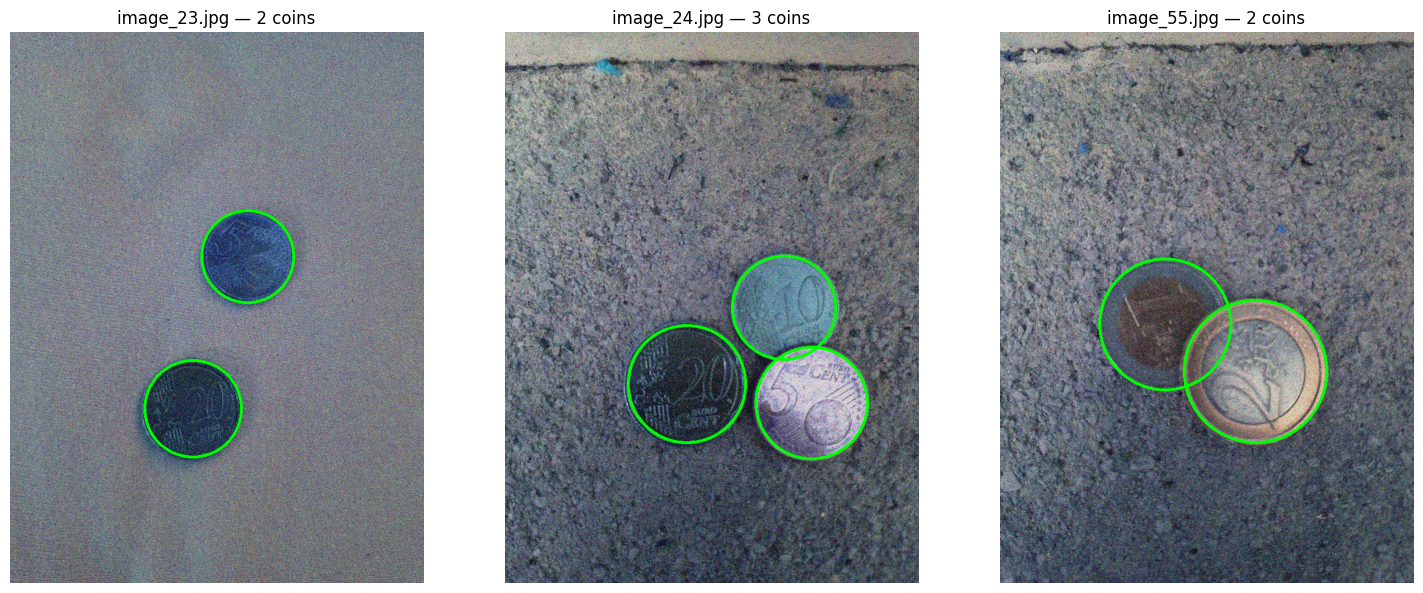

In [32]:
# Demo on three hard scenes: a recovered weak-rim coin (23) and two texture
# backgrounds that used to hallucinate phantoms (24, 55).
demo = ["image_23.jpg", "image_24.jpg", "image_55.jpg"]
fig, axes = plt.subplots(1, len(demo), figsize=(15, 6))
for ax, name in zip(axes, demo):
    img = cv2.imread(str(TGT / name))
    vis = img.copy()
    coins = detect_coins(img)
    for d in coins:
        cv2.circle(vis, (int(d["cx"]), int(d["cy"])), int(d["r"]), (0, 255, 0), 3)
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{name} — {len(coins)} coins"); ax.axis("off")
plt.tight_layout(); plt.show()

## 5. Detection results

Since the target_set is provided without labels, a custom positional ground truth was created to evaluate the detection stage. It covers 99 of the 142 target images, for a total of 227 coins, with a centre and radius associated with each coin.

> Note: coin positions and radii were obtained with the assistance of an LLM in order to reduce the time required for annotation. Therefore, this ground truth is used only as an internal reference for comparing the different detector configurations and should not be considered an official annotation of the dataset.

A predicted circle is associated with a ground-truth coin when their circle IoU is greater than 0.5.

| detector | miss | FP | centre err (median) | radius err (median) |
|---|---:|---:|---:|---:|
| two strict Hough passes + validator | 7 | 11 | 1.9 px | 1.4% |
| + rescue pass with parsimony rule | 0 | 13 | 1.9 px | 1.4% |
| + containment gate | 0 | 7 | 1.9 px | 1.4% |
| + background-similarity gate | 0 | 1 | 1.9 px | 1.4% |
| **+ relative-scale gate (full stage)** | **0** | **1** | 1.9 px | 1.4% |

The relative-scale gate leaves the GT numbers untouched but removes measured phantom pairs in
scenes outside the labelled set (e.g. image_76) with zero regressions. The single residual FP
is a real coin missing from the ground truth itself (image_28, found by the rescue pass).
Design notes and negative ablations (ch.3 prefilter bench: every scene prefilter worsens the
misses; DoG blob detector dominated in all three roles) are kept outside the notebook.

**Known limits.**
1. Scenes shot at a strong angle show elliptical coins; the circular model
fails there (e.g. image_85) — a measured, declared limit.
2. The background gate threshold has
a narrow measured margin (worst FP z = 0.84 vs worst true coin z = 0.90) and is re-validated as
the ground truth grows.

## 6. Classification — cues and design

The detection stage returns the regions of the image likely to contain coins, but does not infer their values. Detection reaches 97.18% count accuracy, while most of the remaining errors are caused by incorrect denomination assignments.

A single feature was not sufficient to reliably distinguish all euro denominations. In particular, some coins have similar shapes or materials, while their physical sizes differ only by a few percent. Due to this ambiguity, the classifier was built to combine five sources of information:

1. **Shape-based matching** against the eight reference coins, using gradient directions at Canny control points and testing different rotations.

2. **Colour family** (copper / gold), estimated relative to the local background and compared with prototypes obtained from the reference images. Colour-family classification was particularly challenging because the colour distribution of the reference samples did not match that of the test set.

3. **Bimetal evidence**, obtained from the colour difference between the inner and outer regions of the coin. The ring colour is also used as an additional cue for distinguishing 1€ and 2€.

4. **SIFT keypoint matching**, performed between the canonical crop of the detected coin and the corresponding reference descriptors.

5. **Relative size**, using the known diameters of euro coins and the fact that coins lying approximately on the same plane share a common image scale.

The individual scores are combined during classification. The shape score is corrected using the average cross-class similarity measured on the reference set. In addition, the `bg_z` value computed during detection is used to reduce the contribution of appearance-based cues when the coin has low contrast with respect to its background.

A few implementation details were also modified during development:

* `crop_disc` preserves the aspect ratio of partially visible coins by padding the missing image region before resizing;
* the shape de-bias term `TEMPLATE_OFFDIAG` is computed from the reference images rather than manually specified;
* SIFT extraction and scoring were revised after the first implementation decreased classification accuracy.

The individual components and their measured effects are discussed in the following sections.


### 6.1 Canonical crops and colour normalisation

Every coin is cropped and resized to a canonical 150×150 disc. This removes the observed pixel scale from the appearance matcher; physical size is instead considered separately at scene level. A fixed affine de-cast (per-channel gain/offset, calibrated once on the references) is used to reduce the global colour cast.

Crops are denoised with non-local means. This differs from the detection stage, where additional smoothing increased the number of missed coins: weak boundaries are important for Hough detection, while here denoising is used to obtain more stable gradient directions for matching.

**Aspect-preserving crop.** `crop_disc` previously clipped the bounding box asymmetrically when a coin was partially outside the image and then resized the remaining non-square patch to a square image. This introduced a geometric distortion in the crop.

The bounding box is now kept square (2r×2r). When part of it lies outside the image, the missing region is padded by edge replication (`cv2.copyMakeBorder`, `BORDER_REPLICATE`) before resizing. This preserves the aspect ratio of the visible part of the coin and avoids introducing additional stretching before classification.


In [33]:
CANON = 150
CLASSES = ["1cent", "2cent", "5cent", "10cent", "20cent", "50cent", "1euro", "2euro"]
FAMILY = {**{c: "copper" for c in ("1cent", "2cent", "5cent")},
          **{c: "gold" for c in ("10cent", "20cent", "50cent")},
          **{c: "bimetal" for c in ("1euro", "2euro")}}
# Fixed affine colour de-cast (gain/offset per BGR channel), calibrated once on the
# reference set: invariance to affine intensity changes (the ZNCC lesson) obtained by correcting
# the image instead of the measure.
CAST_GAIN, CAST_OFF = (0.745, 0.908, 0.722), (14.12, 18.38, 53.97)

_BY, _BX = np.ogrid[:CANON, :CANON]
RHO = np.hypot(_BX - CANON / 2, _BY - CANON / 2) / (CANON / 2)
DMASK = RHO < 0.95                                # inside-disc mask of the canonical crop

def decast(bgr):
    out = bgr.astype(np.float64).copy()
    for ch in range(3):
        out[:, :, ch] = CAST_GAIN[ch] * out[:, :, ch] + CAST_OFF[ch]
    return np.clip(out, 0, 255).astype(np.uint8)

def crop_disc(bgr, cx, cy, r):
    # Square (2r x 2r) crop around the coin, resized to the canonical size (removes
    # scale). A border-clipped coin is padded by edge replication instead of being
    # resized from a clipped, non-square patch - that used to stretch its aspect
    # ratio; this keeps it intact (aspect-crop fix).
    R = int(r); h, w = bgr.shape[:2]
    x0, x1, y0, y1 = cx - R, cx + R, cy - R, cy + R
    if x1 <= 0 or y1 <= 0 or x0 >= w or y0 >= h:
        return None
    pad_l, pad_t = max(0, -x0), max(0, -y0)
    pad_r, pad_b = max(0, x1 - w), max(0, y1 - h)
    patch = bgr[max(0, y0):min(h, y1), max(0, x0):min(w, x1)]
    if patch.size == 0:
        return None
    if pad_l or pad_t or pad_r or pad_b:
        patch = cv2.copyMakeBorder(patch, pad_t, pad_b, pad_l, pad_r, cv2.BORDER_REPLICATE)
    return cv2.resize(patch, (CANON, CANON), interpolation=cv2.INTER_CUBIC)

def nlm(img, h):
    # Non-local means: cleans gradient DIRECTIONS for matching.
    return img if h <= 0 else cv2.fastNlMeansDenoisingColored(
        img, None, h=float(h), hColor=float(h), templateWindowSize=7, searchWindowSize=21)

def rot(img, th):
    M = cv2.getRotationMatrix2D((CANON / 2.0, CANON / 2.0), th, 1.0)
    return cv2.warpAffine(img, M, (CANON, CANON), flags=cv2.INTER_CUBIC,
                          borderMode=cv2.BORDER_CONSTANT, borderValue=0)

def grad_dirs(g):
    gx = cv2.Sobel(g, cv2.CV_32F, 1, 0, 3)
    gy = cv2.Sobel(g, cv2.CV_32F, 0, 1, 3)
    return np.arctan2(gy, gx)

### 6.2 Reference atlas and shape-based matching

For each denomination, a reference model is built from the corresponding reference image. Canny edge points are used as control points and the gradient direction is stored at each location.

The similarity score is defined as the fraction of control points whose gradient direction agrees with the target within ±30°. The comparison uses `cos(2Δθ)`, which makes the score invariant to a reversal of the gradient polarity. Since the coin orientation is unknown, the score is evaluated over the quantised rotations and the maximum value is retained. The score is expressed as a fraction rather than as an absolute number of matching control points, which would otherwise favour the denominations whose atlas contains more points.

The Canny thresholds and NLM strengths are class-specific and were fixed using the reference images. For two denominations, a local blur is also applied to reduce the effect of relief details that produced repeated mismatches.

### Shape-score correction

Some reference models obtain systematically higher scores even when matched against other denominations. To reduce this bias, `TEMPLATE_OFFDIAG` is estimated directly from the reference set.

Each reference crop is matched against the atlases of the other denominations, and the average cross-class score is used as a correction term for that class. This replaces the manually specified constants used in the earlier implementation.

### Reference de-casting

The shape atlas is still built from the original reference images, while the target crop is de-cast before matching.

Using de-cast reference images was also tested. With the remaining configuration unchanged, the measured amount accuracy decreased from 49.30% to 45.77%. For this reason, the original reference images were retained for the atlas.

A possible explanation is that the class-specific Canny thresholds were selected on the contrast distribution of the original reference images, and changing the photometric preprocessing also changes the resulting edge map.


In [34]:
ANGLES = range(0, 360)                       # rotation hypotheses, 1 deg step
TAU = float(np.cos(2 * np.radians(30)))      # direction tolerance, polarity-invariant
# Per-class reference Canny thresholds / NLM strengths (fixed on the references).
REF_EDGE = {"1cent": (5, 30), "2cent": (5, 60), "5cent": (10, 40), "10cent": (20, 60),
            "20cent": (60, 140), "50cent": (10, 40), "1euro": (30, 50), "2euro": (10, 50)}
REF_NLM = {"1cent": 3, "2cent": 2, "5cent": 5, "10cent": 3,
           "20cent": 5, "50cent": 7, "1euro": 3, "2euro": 5}
REF_BLUR = {"5cent": (10, (107, 75, 30)),    # sigma, (x, y, radius) of relief to hide
            "2cent": (10, (100, 60, 40))}
TGT_NLM = 4                                  # NLM strength on target crops

def find_ref_coin(g):
    c = cv2.HoughCircles(cv2.medianBlur(g, 5), cv2.HOUGH_GRADIENT, 1.2, 300,
                         param1=150, param2=30, minRadius=40, maxRadius=300)
    return tuple(map(int, np.round(c[0][0])))

def apply_ref_blur(disc, name):
    if name not in REF_BLUR:
        return disc
    sigma, (bx, by, br) = REF_BLUR[name]
    m = (((_BX - bx) ** 2 + (_BY - by) ** 2) <= br ** 2) & DMASK
    alpha = cv2.GaussianBlur(m.astype(np.float32), (0, 0), 6)[..., None]
    blurred = cv2.GaussianBlur(disc, (0, 0), float(sigma))
    return (disc.astype(np.float32) * (1 - alpha)
            + blurred.astype(np.float32) * alpha).clip(0, 255).astype(np.uint8)

ATLAS, REF_AB, REF_DISCS = {}, {}, {}
for name in CLASSES:
    ref_bgr = cv2.imread(str(REF / f"{name}.jpg"))
    rcx, rcy, rr = find_ref_coin(cv2.cvtColor(ref_bgr, cv2.COLOR_BGR2GRAY))
    raw_crop = crop_disc(ref_bgr, rcx, rcy, rr)
    disc = apply_ref_blur(nlm(raw_crop, REF_NLM[name]), name)
    g = cv2.cvtColor(disc, cv2.COLOR_BGR2GRAY)
    lo, hi = REF_EDGE[name]
    ATLAS[name] = {"cp": (cv2.Canny(g, lo, hi) > 0) & DMASK, "ang": grad_dirs(g)}
    REF_DISCS[name] = nlm(raw_crop, TGT_NLM)     # target-like crop, reused below (offdiag) and for SIFT
    # gentler chain for the COLOUR side of the references (tones, not edges)
    cd = cv2.GaussianBlur(nlm(raw_crop, 1), (0, 0), 0.3)
    lab = cv2.cvtColor(cd, cv2.COLOR_BGR2LAB).astype(np.float32)
    REF_AB[name] = np.array([np.median(lab[:, :, 1][DMASK]),
                             np.median(lab[:, :, 2][DMASK])])
GROUP_AB = {g: np.mean([REF_AB[n] for n in CLASSES if FAMILY[n] == g], axis=0)
            for g in ("copper", "gold", "bimetal")}

def shape_scores(crop):
    # Shape-based matching: fraction of control points whose gradient direction agrees
    # (cos 2*dtheta >= tau), maximised over the quantised rotations.
    angs = [grad_dirs(cv2.cvtColor(rot(crop, th), cv2.COLOR_BGR2GRAY)) for th in ANGLES]
    out = {}
    for name in CLASSES:
        cp, ra = ATLAS[name]["cp"], ATLAS[name]["ang"]
        out[name] = max(float((np.cos(2 * (a[cp] - ra[cp])) >= TAU).mean()) for a in angs)
    return out

# Data-derived per-class shape de-bias (shape de-bias fix): how much does class c's atlas
# match OTHER reference coins' crops on average? Replaces the 8 hand-typed
# TEMPLATE_OFFDIAG constants used originally.
_CROSS_SCORES = {other: shape_scores(REF_DISCS[other]) for other in CLASSES}
TEMPLATE_OFFDIAG = {c: float(np.mean([_CROSS_SCORES[other][c]
                                      for other in CLASSES if other != c]))
                    for c in CLASSES}

### 6.2-bis Why a per-class atlas is used instead of the Generalized Hough Transform

The Generalized Hough Transform is designed to estimate the pose of an object from its edge structure. In this pipeline, however, the coin centre and radius are already estimated during detection, and the crop is resized to a canonical 150×150 representation before classification.

As a consequence, translation and scale have already been handled before the shape comparison. The remaining unknown is mainly the in-plane rotation, which is tested explicitly by evaluating the shape score over the quantised rotation hypotheses.

For classification, the useful information is the agreement between the gradient directions of the model control points and those of the target crop. The score therefore measures the fraction of control points whose orientations are compatible with the target.

A GHT-style implementation based on edge voting was also tested separately. On the target images, its precision was not sufficient for inclusion in the final pipeline, so the per-class control-point atlas was retained instead.

The atlas is built once from the `reference_set` and reused for all target images.


### 6.3 Colour cues — family and bimetal evidence

Colour-family classification was particularly challenging because the colour distribution of the reference samples did not match that of the target images.

For this reason, the coin colour is evaluated relative to the local background rather than using absolute colour values. The median Lab colour of the coin is compared with the median colour of a surrounding annulus, and the resulting difference is compared with two prototypes representing the copper and gold families.

The prototypes are obtained from the mono-metallic reference coins using the same preprocessing applied during classification.

Bimetallic coins are handled separately. The colour difference between the inner region and the outer ring is used as an indicator of a bimetallic structure. The relative colour of the ring is also used as an additional cue to distinguish between 1€ and 2€ coins.

A preliminary score based on shape and colour is computed only to initialise the scene-scale estimation described in §6.5. It is not used as the final classification result.


In [35]:
def lnorm(disc):
    # Per-disc luminance 2-98% stretch (L* only): restores dynamics on dark scenes
    # without touching the chroma the tone cue lives on.
    lab = cv2.cvtColor(disc, cv2.COLOR_BGR2LAB).astype(np.float32)
    L = lab[:, :, 0]
    lo, hi = np.percentile(L[DMASK], [2, 98])
    lab[:, :, 0] = np.clip((L - lo) / max(hi - lo, 1e-6) * 255, 0, 255)
    return cv2.cvtColor(np.clip(lab, 0, 255).astype(np.uint8), cv2.COLOR_LAB2BGR)

def coin_tone(disc):
    lab = cv2.cvtColor(lnorm(disc), cv2.COLOR_BGR2LAB).astype(np.float32)
    inner = RHO < 0.6                        # inner disc avoids the bimetal ring
    return np.array([np.median(lab[:, :, 1][inner]), np.median(lab[:, :, 2][inner])])

def bg_tone(dcx, cx, cy, r):
    # Median (a*, b*) of the peri-coin annulus: the relative-colour anchor.
    h, w = dcx.shape[:2]
    Y, X = np.ogrid[:h, :w]
    d = np.hypot(X - cx, Y - cy)
    ann = (d >= 1.10 * r) & (d <= 1.35 * r)
    if ann.sum() < 50:
        return None
    lab = cv2.cvtColor(dcx, cv2.COLOR_BGR2LAB).astype(np.float32)
    return np.array([np.median(lab[:, :, 1][ann]), np.median(lab[:, :, 2][ann])])

def bimetal_step(disc):
    # Core/ring chroma step: a 1-D edge along the radial colour profile.
    lab = cv2.cvtColor(lnorm(disc), cv2.COLOR_BGR2LAB).astype(np.float32)
    a, b = lab[:, :, 1], lab[:, :, 2]
    core, ring = RHO < 0.55, (RHO >= 0.55) & DMASK
    return float(np.hypot(np.median(a[core]) - np.median(a[ring]),
                          np.median(b[core]) - np.median(b[ring])))

def ring_sign(disc):
    lab = cv2.cvtColor(disc, cv2.COLOR_BGR2LAB).astype(np.float32)
    core_b = float(lab[RHO < 0.45][:, 2].mean())
    ring_b = float(lab[(RHO > 0.75) & (RHO < 0.95)][:, 2].mean())
    return "gold-ring" if ring_b > core_b else "silver-ring"

def dev_tone(dcx, cx, cy, r):
    disc = crop_disc(dcx, cx, cy, r)
    if disc is None:
        return None, None
    bg = bg_tone(dcx, cx, cy, r)
    return coin_tone(disc) - (bg if bg is not None else 0.0), bimetal_step(disc)

# The two fixed prototype tones, from the six mono references through the SAME chain.
_protos = {"copper": [], "gold": []}
for name in CLASSES:
    if FAMILY[name] == "bimetal":
        continue
    ref_bgr = cv2.imread(str(REF / f"{name}.jpg"))
    rcx, rcy, rr = find_ref_coin(cv2.cvtColor(ref_bgr, cv2.COLOR_BGR2GRAY))
    dev, _ = dev_tone(decast(ref_bgr), rcx, rcy, rr)
    _protos[FAMILY[name]].append(dev)
PROTO = {g: np.mean(v, axis=0) for g, v in _protos.items()}
PROTO_SEP = float(np.hypot(*(PROTO["copper"] - PROTO["gold"])))

def two_tone_family(dcx, cx, cy, r):
    # Nearest-of-two-prototypes on the background-anchored tone; abstain on a
    # likely bimetal (the chroma step explains the colour better than a family).
    dev, step = dev_tone(dcx, cx, cy, r)
    if dev is None or step >= 13.0:
        return None, 0.0
    dc = float(np.hypot(*(dev - PROTO["copper"])))
    dg = float(np.hypot(*(dev - PROTO["gold"])))
    conf = float(np.clip(abs(dc - dg) / (PROTO_SEP + 1e-6), 0, 1))
    return ("copper" if dc < dg else "gold"), conf

def ring_chroma(crop):
    # Normalised chroma-gradient radial profile: a bimetal ring leaves a bump at
    # rho 0.60-0.78 (used only inside the first-pass seed below).
    lab = cv2.cvtColor(crop, cv2.COLOR_BGR2LAB).astype(np.float32)
    cg = np.zeros((CANON, CANON), np.float32)
    for ch in (1, 2):
        gx = cv2.Sobel(lab[:, :, ch], cv2.CV_32F, 1, 0, 3)
        gy = cv2.Sobel(lab[:, :, ch], cv2.CV_32F, 0, 1, 3)
        cg += np.hypot(gx, gy)
    rs = np.arange(0.1, 0.95, 0.05)
    prof = np.array([cg[(RHO >= t - 0.025) & (RHO < t + 0.025)].mean() for t in rs])
    prof = prof / (prof.max() + 1e-6)
    return float(prof[(rs >= 0.60) & (rs <= 0.78)].max()
                 - np.median(prof[(rs >= 0.25) & (rs <= 0.55)]))

def first_pass(shp, crop):
    # Seed prediction (shape + soft colour favour): ONLY initialises the scene
    # scale; the joint labelling in S6.5 re-decides every coin.
    lab = cv2.cvtColor(crop, cv2.COLOR_BGR2LAB).astype(np.float32)
    ab = np.array([np.median(lab[:, :, 1][DMASK]), np.median(lab[:, :, 2][DMASK])])
    group = min(GROUP_AB, key=lambda g: float(np.linalg.norm(ab - GROUP_AB[g])))
    spread = float(np.std(list(shp.values()))) + 1e-6
    bi = float(np.clip((ring_chroma(crop) - 0.10) / 0.30, 0.0, 1.0))
    fav = {n: (0.6 * spread if FAMILY[n] == group else 0.0)
           + (1.2 * bi * spread if FAMILY[n] == "bimetal" else 0.0) for n in CLASSES}
    return max(CLASSES, key=lambda n: shp[n] + fav[n])

### 6.4 SIFT keypoint matching

SIFT was introduced as an additional local-feature cue. In its first implementation, however, the measured amount accuracy decreased from 48.59% to 45.07%.

Two problems were identified in that implementation.

1. **Different descriptor scales.** Reference descriptors were extracted from the original uncropped images, while target descriptors were extracted from 150×150 canonical crops. Since `SIFT_NMS_DIST` is expressed in pixels, applying the same value to images at different scales produced very different numbers of retained descriptors. Larger coins in the reference images therefore tended to keep more descriptors.

2. **Score normalisation.** The match score was initially normalised using the total number of good matches across all classes. This made the score dependent on the number of descriptors available for each reference class.

To make the comparison more consistent, reference SIFT descriptors are now extracted from the same 150×150 canonical crops used by the other appearance-based cues. `SIFT_NMS_DIST` was consequently reduced from 10 to 5 pixels.

The score for each denomination is also computed independently as

`good matches / number of reference descriptors`

rather than being normalised across all classes. In this way, denominations with different numbers of retained descriptors can be compared using a match rate rather than an absolute match count.

The resulting SIFT scores are then standardised together with the other classification cues before fusion in §6.5.


In [36]:
SIFT_NFEATURES = 700
SIFT_CONTRAST = 0.04
SIFT_NMS_DIST = 5              # 150x150 canonical crop (the full raw photo needed 10px)
LOWE_RATIO = 0.8

def preprocess_for_sift(gray):
    # CLAHE + bilateral filter: enhances edges before SIFT keypoint detection.
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return cv2.bilateralFilter(clahe.apply(gray), d=9, sigmaColor=75, sigmaSpace=75)

def _nms_keypoints(kp, des):
    if des is None or len(kp) == 0:
        return None
    order = sorted(range(len(kp)), key=lambda i: kp[i].response, reverse=True)
    keep, kept_pos = [], []
    for i in order:
        pt = kp[i].pt
        if all(np.hypot(pt[0] - p[0], pt[1] - p[1]) >= SIFT_NMS_DIST for p in kept_pos):
            keep.append(i)
            kept_pos.append(pt)
    return des[keep] if keep else None

_SIFT = cv2.SIFT_create(nfeatures=SIFT_NFEATURES, contrastThreshold=SIFT_CONTRAST)
_BF = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)

# Reference descriptor cache, built from the SAME canonical crop as the shape atlas
# (REF_DISCS, S6.2) instead of the raw reference photo -- this is the domain-mismatch fix.
SIFT_CACHE = {}
for name in CLASSES:
    gray = cv2.cvtColor(REF_DISCS[name], cv2.COLOR_BGR2GRAY)
    kp, des = _SIFT.detectAndCompute(preprocess_for_sift(gray), None)
    SIFT_CACHE[name] = _nms_keypoints(kp, des)

def sift_extract(gray_roi):
    kp, des = _SIFT.detectAndCompute(preprocess_for_sift(gray_roi), None)
    return _nms_keypoints(kp, des)

def sift_match_scores(des_query):
    # Per-class match RATE (good matches / that class's OWN cached descriptor count)
    # via ratio-test kNN matching -- not divided by the total across classes, so a
    # sparsely-described class isn't structurally penalised (the scoring-bias fix).
    scores = {c: 0.0 for c in CLASSES}
    if des_query is None or len(des_query) < 3:
        return scores
    for cls, tmpl_des in SIFT_CACHE.items():
        if tmpl_des is None or len(tmpl_des) < 2:
            continue
        good = 0
        for pair in _BF.knnMatch(tmpl_des, des_query, k=2):
            if pair is not None and len(pair) == 2:
                m, n = pair
                if m.distance < LOWE_RATIO * n.distance:
                    good += 1
        scores[cls] = good / len(tmpl_des)
    return scores

def sift_confidence(scores):
    # Normalised top1-vs-top2 gap: high only when one class's match rate clearly
    # dominates the runner-up.
    top1, top2 = sorted(scores.values(), reverse=True)[:2]
    if top1 == 0:
        return 0.0
    return float(np.clip((top1 - top2) / (top1 + 1e-6), 0, 1))

### 6.5 Scene-level size reasoning and joint labelling

Physical size provides useful information for distinguishing denominations because the median radius estimation error is approximately 1.4%, while the diameter differences between euro coins are typically larger.

However, pixel radius cannot be compared directly with the physical diameter of a coin without estimating the scale of the scene.

The scene scale is estimated in two ways:

1. **Bimetallic anchor.** If a coin is detected with sufficiently strong bimetal evidence, the hypotheses 1€ and 2€ are used to estimate a possible scene scale `s = r / D`.

   The resulting scale is compared with the independently estimated initial scale. If their disagreement exceeds `ANCHOR_CONSISTENCY_TOL`, the bimetal-based estimate is discarded.

2. **Initial scale estimate.** Otherwise, the scene scale is obtained from the median `r / D` ratio of the preliminary predictions described in §6.3.

The estimated scale is then used to evaluate how compatible each detected radius is with the known euro coin diameters.

Classification is performed jointly for all coins in the scene. Each denomination hypothesis receives a score based on the appearance cues (shape, colour family, bimetal evidence and SIFT) together with the size information.

Pairwise terms are also added to compare the observed radius ratios between coins with the expected ratios between denomination diameters. Since evaluating every possible combination would be expensive, a beam search is used to retain only the highest-scoring partial assignments.

The fusion weights were selected experimentally as described in §8.


In [37]:
# Cue weights, re-tuned by random search (1500 trials) + 3 passes of coordinate-ascent
# refinement against data/coin_dataset/gt.csv over the full 142-image target set (see S8).
# RATIO_TOL/SAME_TOL/REL_W/BEAM_K and the BIM_START/BIM_FULL pair are untouched.
TEMPLATE_W, TEMPLATE_ALPHA = 1.120312091692299, 0.46282535252112333
FAM_POS, FAM_NEG = 0.47203650129702585, 0.7094389741071441
BIM_START, BIM_FULL = 2.5, 10.5
BIM_POS, BIM_NEG, BIM_RING = 5.7862640527246105, 1.757201100008255, 0.1457475687122199
FAM_BIM_SUP, BIM_FAM_SUP, BIM_FAM_MIN = 0.6546458793832082, 0.7638192098773395, 0.20998934153881837
W_ORDER, W_SAME, REL_W, BEAM_K = 0.5814595192882499, 0.15291231276135417, 0.75, 256
RATIO_TOL, SAME_TOL = 0.18, 0.045
C1_FLOOR, C1_ZLO, C1_ZHI = 0.1311294927519002, 1.5, 4.0       # bg_z legibility damping
ANCHOR_CONF, ANCHOR_W = 0.5267327931386852, 6.421073568211093 # bimetal absolute scale anchor
ANCHOR_CONSISTENCY_TOL = 0.5047183128146107                   # new: max tolerated anchor/seed disagreement
W_SIFT, SIFT_FLOOR = 1.794831084866778, 0.014706133643594299
LOGMAX = float(np.log(25.75 / 16.25))

def zscore(d):
    v = np.array([d[c] for c in CLASSES], np.float64)
    s = float(v.std())
    if s < 1e-6:
        return {c: 0.0 for c in CLASSES}
    return {c: float((d[c] - v.mean()) / s) for c in CLASSES}

def bm_conf(step):
    return float(np.clip((step - BIM_START) / (BIM_FULL - BIM_START), 0, 1))

def pair_score(ri, rj, li, lj):
    # Pairwise size consistency: radius ratios are metric within a planar scene.
    obs = np.log(max(1e-6, ri / rj))
    exp = np.log(DIAMETER_MM[li] / DIAMETER_MM[lj])
    s = -1.15 * min(abs(obs - exp) / RATIO_TOL, 1.8)
    if li == lj:
        s += 0.55 * max(0.0, 1.0 - abs(obs) / SAME_TOL)
    elif abs(obs) < SAME_TOL:
        s -= 0.35
    if (obs > SAME_TOL and exp < -SAME_TOL) or (obs < -SAME_TOL and exp > SAME_TOL):
        s -= 0.9                                # hard ordering violation
    return s

def abs_anchor(coins):
    # Absolute scene scale from a confirmed bimetal: the trusted (coin, class)
    # hypothesis that maps ALL radii best onto the legal diameters.
    best = None
    for c in coins:
        if bm_conf(c["step"]) < ANCHOR_CONF:
            continue
        for cls in ("1euro", "2euro"):
            s = c["r"] / DIAMETER_MM[cls]
            cost = sum(min(abs(np.log((cc["r"] / s) / DIAMETER_MM[k])) for k in CLASSES)
                       for cc in coins)
            if best is None or cost < best[0]:
                best = (cost, s)
    return None if best is None else best[1]

def beam_assign(unaries, radii):
    beam = [([], 0.0)]
    for i, unary in enumerate(unaries):
        nxt = []
        for labels, score in beam:
            for lab in CLASSES:
                p = sum(REL_W * pair_score(radii[i], radii[j], lab, prev)
                        for j, prev in enumerate(labels))
                nxt.append((labels + [lab], score + unary[lab] + p))
        nxt.sort(key=lambda x: x[1], reverse=True)
        beam = nxt[:BEAM_K]
    return beam[0][0]

def classify_scene(img, dets):
    if not dets:
        return []
    dcx = decast(img)
    circles = [(int(round(d["cx"])), int(round(d["cy"])), int(round(d["r"]))) for d in dets]
    coins = []
    for (cx, cy, r), det in zip(circles, dets):
        crop = crop_disc(dcx, cx, cy, r)
        crop = None if crop is None else nlm(crop, TGT_NLM)
        if crop is None:
            coins.append(None)
            continue
        shp = shape_scores(crop)
        fam, fam_conf = two_tone_family(dcx, cx, cy, r)
        disc = crop_disc(dcx, cx, cy, r)
        crop_gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
        sift_scores = sift_match_scores(sift_extract(crop_gray))
        sift_conf = sift_confidence(sift_scores)
        coins.append({"r": r, "bg_z": float(det.get("bg_z", 9.9)), "shape": shp,
                      "pred0": first_pass(shp, crop), "fam": fam, "fam_conf": fam_conf,
                      "step": bimetal_step(disc), "ring": ring_sign(disc),
                      "sift_scores": sift_scores, "sift_conf": sift_conf})
    full = [c for c in coins if c]
    if not full:
        return ["20cent"] * len(dets)
    # scene scale seeded by the first pass; per-class radius medians for the
    # same-class consistency term
    sscale = float(np.median([c["r"] / DIAMETER_MM[c["pred0"]] for c in full]))
    rclass = {}
    for c in full:
        rclass.setdefault(c["pred0"], []).append(c["r"])
    rclass = {k: float(np.median(v)) for k, v in rclass.items()}
    s_abs = abs_anchor(full)
    if s_abs is not None and abs(np.log(s_abs / sscale)) > ANCHOR_CONSISTENCY_TOL:
        s_abs = None                # anchor disagrees too much with the seed: fall back (S6.5 fix)
    unaries, radii, idx = [], [], []
    for i, coin in enumerate(coins):
        if coin is None:
            continue
        template = {c: TEMPLATE_W * v for c, v in zscore(
            {c: coin["shape"][c] - TEMPLATE_ALPHA * TEMPLATE_OFFDIAG[c]
             for c in CLASSES}).items()}
        fam_sc = {c: 0.0 for c in CLASSES}
        if coin["fam"]:
            for c in CLASSES:
                fam_sc[c] = (FAM_POS if FAMILY[c] == coin["fam"]
                             else -FAM_NEG) * coin["fam_conf"]
        bm = bm_conf(coin["step"])
        bim = {c: (BIM_POS if FAMILY[c] == "bimetal" else -BIM_NEG) * bm for c in CLASSES}
        if bm > 0:
            hi, lo2 = (("1euro", "2euro") if coin["ring"] == "gold-ring"
                       else ("2euro", "1euro"))
            bim[hi] += BIM_RING * bm
            bim[lo2] -= 0.5 * BIM_RING * bm
        # family and bimetal are competing material explanations: mutual damping
        if coin["fam"] and bm > 0:
            fs = max(0.05, 1.0 - FAM_BIM_SUP * bm)
            bs = max(BIM_FAM_MIN, 1.0 - BIM_FAM_SUP * coin["fam_conf"] * (1.0 - 0.5 * bm))
            fam_sc = {c: v * fs for c, v in fam_sc.items()}
            bim = {c: v * bs for c, v in bim.items()}
        # SIFT, z-scored across classes like the shape template (S6.4 fix) instead of
        # a hand-picked linear remap of a per-class rate that no longer sums to 1.
        sift_sc = ({c: W_SIFT * v for c, v in zscore(coin["sift_scores"]).items()}
                   if any(coin["sift_scores"].values()) else {c: 0.0 for c in CLASSES})
        sift_norm = SIFT_FLOOR + (1 - SIFT_FLOOR) * coin["sift_conf"]
        sift_sc = {c: v * sift_norm for c, v in sift_sc.items()}
        # bg_z legibility damping of the appearance cues (shape + family + sift)
        damp = C1_FLOOR + (1 - C1_FLOOR) * float(
            np.clip((coin["bg_z"] - C1_ZLO) / (C1_ZHI - C1_ZLO), 0, 1))
        d_obs = coin["r"] / sscale
        unary = {}
        for c in CLASSES:
            u = (damp * (template[c] + fam_sc[c] + sift_sc[c]) + bim[c]
                 - W_ORDER * min(abs(np.log(d_obs / DIAMETER_MM[c])) / LOGMAX, 1.0)
                 - W_SAME * (min(abs(np.log(coin["r"] / rclass[c])) / LOGMAX, 1.0)
                             if c in rclass else 0.0))
            if s_abs is not None:
                u -= ANCHOR_W * min(abs(np.log((coin["r"] / s_abs)
                                               / DIAMETER_MM[c])) / LOGMAX, 1.0)
            unary[c] = u
        unaries.append(unary)
        radii.append(coin["r"])
        idx.append(i)
    beam_labels = beam_assign(unaries, radii)
    labels, k = [], 0
    for i, coin in enumerate(coins):
        if coin is None:                       # off-frame crop: nearest legal diameter
            d_obs = circles[i][2] / sscale
            labels.append(min(CLASSES, key=lambda c: abs(np.log(d_obs / DIAMETER_MM[c]))))
        else:
            labels.append(beam_labels[k])
            k += 1
    return labels

### 6.6 Effect of combining the classification cues

The following three configurations were evaluated on the same 142-image target set while keeping the detection stage unchanged.

| # | configuration                                                               | cues | count acc. | amount acc. |
| - | --------------------------------------------------------------------------- | ---: | ---------: | ----------: |
| 1 | shape + colour family + bimetal + size                                      |    4 |     97.18% |      48.59% |
| 2 | #1 + initial SIFT implementation                                            |    5 |     97.18% |      45.07% |
| 3 | #1 + revised SIFT implementation (§6.4), with re-fitted fusion weights (§9) |    5 |     97.18% |      53.52% |

The first SIFT implementation reduced amount accuracy from 48.59% to 45.07%. As discussed in §6.4, this version used descriptors extracted at different image scales and a score normalisation that depended on the number of reference descriptors.

After extracting the reference descriptors from the canonical crops and changing the score to a per-class match rate, the final configuration reached 53.52% amount accuracy.

Count accuracy remains 97.18% in all three configurations because the detection stage is unchanged. The differences in amount accuracy therefore come from the classification stage.

These experiments do not provide a complete ablation of every individual cue, since shape, colour and bimetal evidence were not evaluated separately. The results only show that the initial SIFT implementation decreased performance, while the revised version improved the complete classifier.

Several additional variants were also evaluated under four-fold cross-validation, including a multi-exemplar reference atlas, a learned fusion classifier, a size-first classification scheme, retuning of the Canny parameters, ORB instead of SIFT, and removal of two manually selected adjustments. None produced a higher result than the final configuration.


## 7. Full pipeline and required output

In [38]:
def process_image(img):
    dets = detect_coins(img)
    return [{**d, "pred": lab, "value": VALUE[lab]}
            for d, lab in zip(dets, classify_scene(img, dets))]

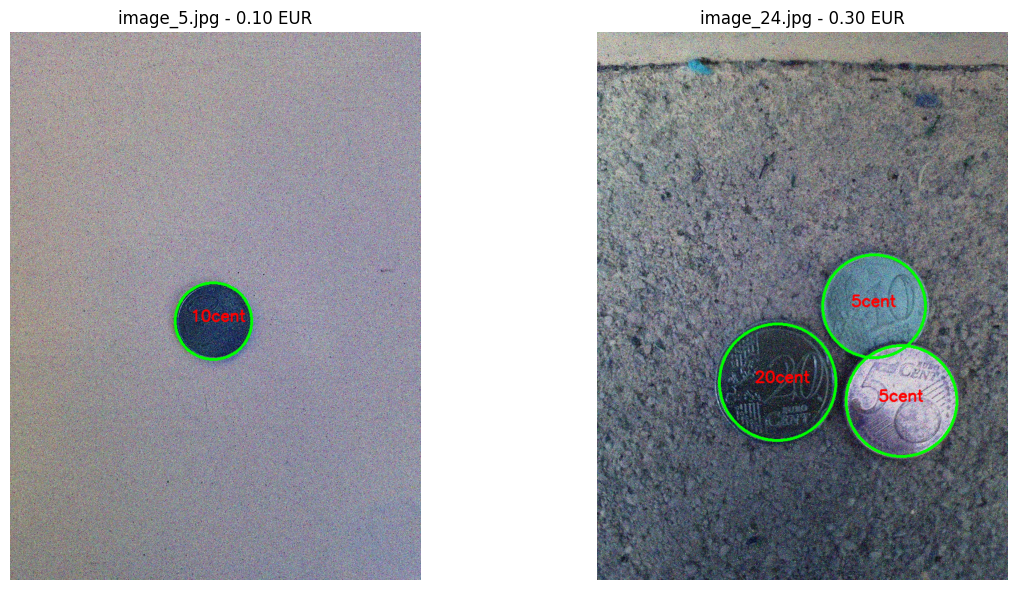

In [39]:
# Demo: classified overlays on two scenes classified overlays on two scenes (a clean one, a texture one).
demo = ["image_5.jpg", "image_24.jpg"]
fig, axes = plt.subplots(1, len(demo), figsize=(13, 6))
for ax, name in zip(axes, demo):
    img = cv2.imread(str(TGT / name))
    coins = process_image(img)
    vis = img.copy()
    for c in coins:
        cv2.circle(vis, (int(c["cx"]), int(c["cy"])), int(c["r"]), (0, 255, 0), 3)
        cv2.putText(vis, c["pred"], (int(c["cx"]) - 40, int(c["cy"])),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2, cv2.LINE_AA)
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{name} - {sum(c['value'] for c in coins):.2f} EUR")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [40]:
# Final run over the whole target set, in the required output format.
total = 0.0
for path in sorted(TGT.iterdir(), key=lambda p: int(p.stem.split("_")[1])):
    coins = process_image(cv2.imread(str(path)))
    print(f"{path.name} - {len(coins)} coin(s) found:")
    for i, c in enumerate(coins, 1):
        print(f"  Coin {i} {{value: {c['value']:.3f}}}")
    partial = sum(c["value"] for c in coins)
    total += partial
    print(f"  Partial Amount {{value: {partial:.3f}}}")
print(f"\nTotal Amount: {total:.2f} EUR")

image_1.jpg - 3 coin(s) found:
  Coin 1 {value: 0.050}
  Coin 2 {value: 0.020}
  Coin 3 {value: 0.010}
  Partial Amount {value: 0.080}
image_2.jpg - 1 coin(s) found:
  Coin 1 {value: 0.100}
  Partial Amount {value: 0.100}
image_3.jpg - 6 coin(s) found:
  Coin 1 {value: 0.010}
  Coin 2 {value: 0.050}
  Coin 3 {value: 0.020}
  Coin 4 {value: 0.020}
  Coin 5 {value: 0.050}
  Coin 6 {value: 0.010}
  Partial Amount {value: 0.160}
image_4.jpg - 1 coin(s) found:
  Coin 1 {value: 0.010}
  Partial Amount {value: 0.010}
image_5.jpg - 1 coin(s) found:
  Coin 1 {value: 0.100}
  Partial Amount {value: 0.100}
image_6.jpg - 1 coin(s) found:
  Coin 1 {value: 0.200}
  Partial Amount {value: 0.200}
image_7.jpg - 3 coin(s) found:
  Coin 1 {value: 0.050}
  Coin 2 {value: 0.500}
  Coin 3 {value: 0.500}
  Partial Amount {value: 1.050}
image_8.jpg - 1 coin(s) found:
  Coin 1 {value: 0.500}
  Partial Amount {value: 0.500}
image_9.jpg - 1 coin(s) found:
  Coin 1 {value: 0.500}
  Partial Amount {value: 0.500}
i

## 8. Classification — results, experiments and limitations

The classification results are evaluated using the custom ground truth described previously. The original evaluation also included a per-coin annotation on a 99-image / 227-coin subset, for which a per-coin accuracy of 0.734 was reported.

For all 142 target images, `gt.csv` provides the expected number of coins and their total monetary value. The evaluation therefore uses:

```python
count_ok  = detected_count == gt["coins"]
amount_ok = abs(detected_total - gt["total"]) < 1e-6
```

`amount_ok` is considerably stricter than the count metric because denomination errors usually change the total value of the image. However, it should be noted that it evaluates the final monetary sum rather than the identity of every individual coin.

For reference, if a per-coin correctness probability of 0.734 were assumed to be independent across four coins, the probability of classifying all four correctly would be approximately `0.734⁴ ≈ 29%`. This is only an illustrative comparison, since classification errors are not necessarily independent.

### Changes and measured results

| variant                                                           | amount accuracy (142 images) |
| ----------------------------------------------------------------- | ---------------------------: |
| original pipeline                                                 |                       48.59% |
| + aspect-preserving `crop_disc` + data-derived `TEMPLATE_OFFDIAG` |                       49.30% |
| + de-cast reference atlas                                         |            45.77% — reverted |
| + revised SIFT + consistency-checked anchor + re-fitted weights   |                   **53.52%** |

Applying the de-cast transformation to the reference atlas reduced accuracy from 49.30% to 45.77%, so this modification was reverted.

One possible explanation is that the class-specific `REF_EDGE` thresholds were selected using the contrast characteristics of the original reference images. Changing the photometric preprocessing also changes the Canny edge maps, so those thresholds may no longer be appropriate.

### Generalisation

The final 53.52% result is measured on the same 142 images used to select the fusion weights and should therefore be considered an in-sample result rather than an estimate of performance on unseen data.

Two-fold cross-validation produced approximately 48–51% held-out amount accuracy, while a four-fold protocol produced approximately 48.6%. These values provide a more conservative estimate of the performance of the complete classifier.

The difference between training and validation accuracy is relatively large in some folds, reaching approximately 65% versus 48%. This suggests that the weight selection is sensitive to the available training images and that the exact fitted values should not be interpreted as optimal.

### Additional experiments

Several alternative configurations were also tested during earlier iterations of the classifier, including:

* validator-support damping;
* a family shortlist with increased size weighting;
* scene-scale estimation based only on scale consensus;
* retuning of the reference Canny/NLM parameters;

None of these configurations improved the final result, so none was retained.

### Known limitations

Most remaining classification errors occur between denominations of the same material family, particularly 20c/50c and 1c/2c.

The method also assumes approximately circular coin projections, so images captured from strong viewing angles remain difficult. In addition, only one reference image is available for each denomination. The resulting reference models therefore cannot represent all the lighting, wear and appearance variations present in the target set.


## 9. Appendix — fusion-weight selection

> **Scope of the optimisation.** Only the fusion weights that determine the relative influence of the different cues are optimised. The visual features, detection stages and geometric constraints remain unchanged.


The 18 fusion parameters used in §6.5 were selected automatically using `gt.csv` rather than being manually assigned.

The optimisation procedure and its validation are described here because these parameters are estimated from the target data and therefore require a separate evaluation of their generalisation performance.

### 9.1 Optimisation objective

The search does not optimise `amount_accuracy` directly. This metric is binary at image level: an image either has the correct final amount or it does not, so many small changes in the classification scores produce no change in the objective.

Instead, the search minimises the mean absolute error between the predicted and expected monetary value of each image. For example, confusing 1c with 2c produces a smaller error than confusing 1c with 2€.

Amount accuracy is still used for the final evaluation in §8.

### 9.2 Feature caching

Some parts of the classification pipeline are independent of the fusion weights. Detection, shape matching over the 360 rotations, colour features and SIFT descriptors therefore only need to be computed once for each image.

These intermediate features are cached before the parameter search. Each candidate set of weights then requires only the fusion and beam-search stages to be recomputed.

This reduces the evaluation time from approximately 2 s per image to approximately 5 ms per image and makes a larger number of parameter evaluations practical.

### 9.3 Parameters included in the search

The search is limited to the 18 fusion parameters listed in `BOUNDS`.

The following parameters are kept fixed:

* `RATIO_TOL`, `SAME_TOL`, `BEAM_K`, `REL_W` and `LOGMAX`;
* `BIM_START` and `BIM_FULL`;
* `TEMPLATE_OFFDIAG`.

`TEMPLATE_OFFDIAG` is treated separately because it is computed only from the eight reference images as described in §6.2 and does not use `gt.csv`.

The search starts from the original parameter values and first performs random search. The resulting solution is then refined by changing one parameter at a time and retaining changes that reduce the mean absolute value error.


In [41]:
# ---------------------------------------------------------------------------
# S9 -- the weight search that produced the constants in S6.5.
#
# Guarded: a full run is ~30-40 min (and the cross-validated protocol behind the
# S8 numbers is several such runs), so it is documented and reproducible but not
# executed when the notebook is run top to bottom.
#
# The search operates on a cache built once per image, holding the per-coin cue
# vectors produced by the expensive half of classify_scene (S9.2); `fuse` below
# stands for its cheap half, re-run for every candidate weight vector.
# ---------------------------------------------------------------------------
RUN_TUNING = False

# (lo, hi) sampling bounds -- the 18 searched weights, and only those (S9.3).
BOUNDS = {
    "TEMPLATE_W": (0.05, 1.8),   "TEMPLATE_ALPHA": (0.0, 0.8),
    "FAM_POS": (0.1, 6.0),       "FAM_NEG": (0.3, 3.5),
    "BIM_POS": (0.5, 7.0),       "BIM_NEG": (0.2, 2.5),      "BIM_RING": (0.0, 0.6),
    "FAM_BIM_SUP": (0.3, 1.0),   "BIM_FAM_SUP": (0.3, 1.0),  "BIM_FAM_MIN": (0.0, 0.4),
    "W_ORDER": (0.02, 0.7),      "W_SAME": (0.02, 0.4),
    "ANCHOR_CONF": (0.1, 0.8),   "ANCHOR_W": (0.0, 7.0),
    "ANCHOR_CONSISTENCY_TOL": (0.02, 1.2),                   "C1_FLOOR": (0.05, 0.7),
    "W_SIFT": (0.0, 3.5),        "SIFT_FLOOR": (0.0, 1.0),
}

# Starting point: the original hand-picked values, so the search must earn its keep.
DEFAULTS = {
    "TEMPLATE_W": 0.5, "TEMPLATE_ALPHA": 0.2, "FAM_POS": 3.4, "FAM_NEG": 1.45,
    "BIM_POS": 4.0, "BIM_NEG": 1.0, "BIM_RING": 0.16,
    "FAM_BIM_SUP": 0.92, "BIM_FAM_SUP": 0.75, "BIM_FAM_MIN": 0.15,
    "W_ORDER": 0.25, "W_SAME": 0.15, "ANCHOR_CONF": 0.4, "ANCHOR_W": 4.0,
    "ANCHOR_CONSISTENCY_TOL": 0.35, "C1_FLOOR": 0.3, "W_SIFT": 1.0, "SIFT_FLOOR": 0.3,
}

def evaluate(cache, weights):
    # Applies a weight vector and scores it. Returns both the surrogate the search
    # minimises (mean absolute euro error, S9.1) and the accuracy S8 reports.
    globals().update(weights)
    amount_ok, abs_err = 0, 0.0
    for item in cache:
        labels = fuse(item)                       # cheap half only: fusion + beam search
        err = abs(round(sum(VALUE[l] for l in labels), 2) - item["gt"]["total"])
        abs_err += err
        amount_ok += (err < 1e-6)
    return abs_err / len(cache), amount_ok / len(cache)

def random_search(cache, n_trials=1500, seed=0):
    rng = random.Random(seed)
    best_w = dict(DEFAULTS)
    best_err, _ = evaluate(cache, best_w)
    for _ in range(n_trials):
        trial = {k: rng.uniform(lo, hi) for k, (lo, hi) in BOUNDS.items()}
        err, _ = evaluate(cache, trial)
        if err < best_err:
            best_err, best_w = err, trial
    return best_w, best_err

def coordinate_ascent(cache, start, passes=3):
    # Refines one weight at a time, keeping any move that lowers the surrogate.
    cur = dict(start)
    best_err, _ = evaluate(cache, cur)
    for _ in range(passes):
        improved = False
        for name, (lo, hi) in BOUNDS.items():
            span = hi - lo
            for d in (-0.3, -0.15, -0.05, 0.05, 0.15, 0.3):
                trial = dict(cur, **{name: max(lo, min(hi, cur[name] + d * span))})
                err, _ = evaluate(cache, trial)
                if err < best_err - 1e-9:
                    best_err, cur, improved = err, trial, True
        if not improved:
            break                                 # converged: no single move helps
    return cur, best_err

def cross_validate(cache, seed=0):
    # Two-fold, odd/even image split. THIS is the honest estimate: each fold's
    # validation half was never seen by the search that produced its weights.
    idx = lambda c: int(c["filename"].split("_")[1].split(".")[0])
    odd = [c for c in cache if idx(c) % 2 == 1]
    even = [c for c in cache if idx(c) % 2 == 0]
    out = []
    for train, val in ((odd, even), (even, odd)):
        w, _ = coordinate_ascent(train, random_search(train, seed=seed)[0])
        globals().update(w)
        _, train_acc = evaluate(train, w)
        _, val_acc = evaluate(val, w)
        out.append((train_acc, val_acc))          # the train/val gap reported in S8
    return out

if RUN_TUNING:
    import random
    cache = build_feature_cache(TARGET_DIR)       # the expensive half, run once (S9.2)
    print("cross-validated:", cross_validate(cache))
    weights, err = coordinate_ascent(cache, random_search(cache)[0])
    print("shipped (in-sample) fit:", weights, err)

### 9.4 Results of the parameter search

| protocol                    | search budget          | held-out amount accuracy | fold range      |
| --------------------------- | ---------------------- | -----------------------: | --------------- |
| 2-fold CV                   | 1500 trials / 3 passes |                  ~48–51% | fold-dependent  |
| 4-fold CV, screening budget | 500 trials / 2 passes  |                   53.43% | 42.86% – 61.11% |
| 4-fold CV, full budget      | 1500 trials / 3 passes |               **48.55%** | 42.86% – 55.56% |
| full-data fit (in-sample)   | 1500 trials / 3 passes |                   53.52% | —               |

Increasing the search budget in the four-fold experiment reduced the held-out accuracy from 53.43% to 48.55%. Since the dataset partition and the optimisation procedure were unchanged, this behaviour is consistent with the larger search fitting the training folds more closely without improving generalisation.

The relatively large variation between folds also indicates that the exact accuracy depends considerably on the available training images.

The final weights used in §6.5 are obtained by fitting the complete 142-image dataset and reach 53.52% on the same data. This value is therefore reported as an in-sample result. The cross-validation results, particularly the 48.55% obtained with the full search budget, provide a more conservative estimate of performance on unseen images.

## 10. References

**Course material.**
G. Lisanti, *Image Processing and Computer Vision — Part 1*, University of Bologna, a.y. 2025/2026.

### Techniques covered in the course and related original sources

1. **J. Canny**, *A computational approach to edge detection*, IEEE Transactions on Pattern Analysis and Machine Intelligence, 8(6):679–698, 1986.
   — Canny edge detection, used for edge extraction in §2 and for the reference atlas in §6.2.
   [DOI: 10.1109/TPAMI.1986.4767851](https://doi.org/10.1109/TPAMI.1986.4767851)

2. **R. O. Duda, P. E. Hart**, *Use of the Hough transformation to detect lines and curves in pictures*, Communications of the ACM, 15(1):11–15, 1972.
   — Hough-based candidate generation (§1).
   [DOI: 10.1145/361237.361242](https://doi.org/10.1145/361237.361242)

3. **D. H. Ballard**, *Generalizing the Hough transform to detect arbitrary shapes*, Pattern Recognition, 13(2):111–122, 1981.
   — Generalized Hough Transform, discussed in §6.2-bis.
   [DOI: 10.1016/0031-3203(81)90009-1](https://doi.org/10.1016/0031-3203%2881%2990009-1)

4. **C. Steger**, *Occlusion, clutter, and illumination invariant object recognition*, ISPRS Archives, 34:345–350, 2002.
   — Shape-based matching using oriented control points (§6.2).
   [Official paper](https://www.isprs.org/proceedings/xxxiv/part3/papers/paper006.pdf)

5. **D. G. Lowe**, *Distinctive image features from scale-invariant keypoints*, International Journal of Computer Vision, 60(2):91–110, 2004.
   — SIFT and nearest-neighbour ratio matching (§6.4).
   [DOI: 10.1023/B:VISI.0000029664.99615.94](https://doi.org/10.1023/B:VISI.0000029664.99615.94)

### Techniques beyond the course syllabus

6. **I. Kása**, *A circle fitting procedure and its error analysis*, IEEE Transactions on Instrumentation and Measurement, 25(1):8–14, 1976.
   — Algebraic circle fitting (§2).
   [DOI: 10.1109/TIM.1976.6312298](https://doi.org/10.1109/TIM.1976.6312298)

7. **N. Chernov, C. Lesort**, *Least squares fitting of circles*, Journal of Mathematical Imaging and Vision, 23(3):239–252, 2005.
   — Analysis of least-squares circle fitting (§2).
   [DOI: 10.1007/s10851-005-0482-8](https://doi.org/10.1007/s10851-005-0482-8)

8. **P. J. Rousseeuw, C. Croux**, *Alternatives to the median absolute deviation*, Journal of the American Statistical Association, 88(424):1273–1283, 1993.
   — Robust scale estimation and MAD-related estimators (§3).
   [DOI: 10.1080/01621459.1993.10476408](https://doi.org/10.1080/01621459.1993.10476408)

9. **F. R. Hampel**, *The influence curve and its role in robust estimation*, Journal of the American Statistical Association, 69(346):383–393, 1974.
   — Robust estimation (§3).
   [DOI: 10.1080/01621459.1974.10482962](https://doi.org/10.1080/01621459.1974.10482962)

10. **M. A. Fischler, R. C. Bolles**, *Random sample consensus: A paradigm for model fitting with applications to image analysis and automated cartography*, Communications of the ACM, 24(6):381–395, 1981.
    — RANSAC, considered as an alternative robust fitting strategy in §2.
    [DOI: 10.1145/358669.358692](https://doi.org/10.1145/358669.358692)

11. **C. Tomasi, R. Manduchi**, *Bilateral filtering for gray and color images*, Proceedings of the IEEE International Conference on Computer Vision (ICCV), 1998.
    — Bilateral filtering (§2).
    [DOI: 10.1109/ICCV.1998.710815](https://doi.org/10.1109/ICCV.1998.710815)

12. **A. Buades, B. Coll, J.-M. Morel**, *A non-local algorithm for image denoising*, Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR), 2005.
    — Non-local means denoising (§6.1).
    [DOI: 10.1109/CVPR.2005.38](https://doi.org/10.1109/CVPR.2005.38)

13. **K. Zuiderveld**, *Contrast Limited Adaptive Histogram Equalization*, in *Graphics Gems IV*, Academic Press, pp. 474–485, 1994.
    — CLAHE preprocessing before SIFT extraction (§6.4).
    [DOI: 10.1016/B978-0-12-336156-1.50061-6](https://doi.org/10.1016/B978-0-12-336156-1.50061-6)
